In [3]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import entropy

# Paths
IN_DIR = "../data/processed"
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

RES_FILE   = os.path.join(IN_DIR, "resource_features_with_outliers.csv")
CASE_HYB   = os.path.join(IN_DIR, "case_hybrid_scores.csv")
EVENT_FILE = os.path.join(IN_DIR, "event_scores.csv")
OUT_FILE   = os.path.join(OUT_DIR, "resource_hybrid_scores.csv")

# Load datasets
res_df   = pd.read_csv(RES_FILE, low_memory=False)
case_hyb = pd.read_csv(CASE_HYB, low_memory=False)
event_df = pd.read_csv(EVENT_FILE, low_memory=False)

print("Loaded:")
print("resource_df:", res_df.shape)
print("case_hybrid:", case_hyb.shape)
print("event_scores:", event_df.shape)


Loaded:
resource_df: (64, 13)
case_hybrid: (3183, 4)
event_scores: (262628, 13)


In [4]:
required_res = [
    "resource",
    "n_events",
    "n_unique_cases",
    "n_distinct_activities",
    "avg_wait_before_event_hours",
    "avg_inter_event_hours",
    "handover_in",
    "handover_out"
]

missing = [c for c in required_res if c not in res_df.columns]
if missing:
    raise KeyError(f"Missing columns in resource_features: {missing}")

if "case_hybrid_score" not in case_hyb.columns:
    raise KeyError("case_hybrid_scores.csv missing case_hybrid_score")

if "event_score" not in event_df.columns:
    raise KeyError("event_scores.csv missing event_score")

print("Validation complete.")


Validation complete.


In [5]:
# Map case_id → hybrid score
case_map = case_hyb.set_index("case_id")["case_hybrid_score"]

# Attach case hybrid score to each event
event_df["case_hybrid"] = event_df["case_id"].map(case_map)

# Replace missing with median
event_df["case_hybrid"] = event_df["case_hybrid"].fillna(case_hyb["case_hybrid_score"].median())

# Aggregate per resource
res_case_avg = (
    event_df.groupby("resource")["case_hybrid"]
            .mean()
            .rename("avg_case_hybrid_for_resource")
            .reset_index()
)

print("Aggregated avg case hybrid scores per resource:")
display(res_case_avg.head())


Aggregated avg case hybrid scores per resource:


,resource,avg_case_hybrid_for_resource
0,10716070,0.214552
1,1550894,0.385777
2,1946514,0.724556
3,2013365,0.408675
4,2670601,0.643888


In [6]:
res_event_avg = (
    event_df.groupby("resource")["event_score"]
            .mean()
            .rename("avg_event_score_for_resource")
            .reset_index()
)

print("Aggregated avg event scores per resource:")
display(res_event_avg.head())


Aggregated avg event scores per resource:


,resource,avg_event_score_for_resource
0,10716070,0.478354
1,1550894,0.512573
2,1946514,0.660372
3,2013365,0.523138
4,2670601,0.680668


In [7]:
res = res_df.copy()

# Merge case-hybrid averages
res = res.merge(res_case_avg, on="resource", how="left")

# Merge event-score averages
res = res.merge(res_event_avg, on="resource", how="left")

# Outlier penalty from resource_features
if "res_outlier" in res.columns:
    res["outlier_penalty_resource"] = res["res_outlier"].astype(float)
else:
    res["outlier_penalty_resource"] = 0.0

# Fill missing values
res = res.fillna(res.median(numeric_only=True))

print("Merged resource feature table:")
display(res.head())


Merged resource feature table:


,resource,n_events,n_unique_cases,n_distinct_activities,handover_in,handover_out,avg_wait_before_event_seconds,avg_inter_event_seconds,avg_wait_before_event_hours,avg_inter_event_hours,avg_events_per_case,municipality,res_outlier,avg_case_hybrid_for_resource,avg_event_score_for_resource,outlier_penalty_resource
0,10716070,96,2,54,7.0,7.0,425633.684211,550325.274725,118.231579,152.868132,48.000000,BPIC15_1,True,0.214552,0.478354,1.0
1,1550894,12875,169,217,900.0,900.0,124427.269143,188601.153028,34.563130,52.389209,76.183432,BPIC15_4,True,0.385777,0.512573,1.0
2,1946514,180,4,63,0.0,0.0,80938.909091,77910.079309,22.483030,21.641689,45.000000,BPIC15_3,False,0.724556,0.660372,0.0
3,2013365,12905,184,210,793.0,793.0,89306.013834,128354.362852,24.807226,35.653990,70.135870,BPIC15_3,True,0.408675,0.523138,1.0
4,2670601,1363,45,146,61.0,61.0,161186.050038,174905.738252,44.773903,48.584927,30.288889,BPIC15_1,False,0.643888,0.680668,0.0


In [8]:
lower_is_better = [
    "avg_wait_before_event_hours",
    "avg_inter_event_hours",
    "handover_out",
    "outlier_penalty_resource"
]

higher_is_better = [
    "n_events",
    "n_unique_cases",
    "n_distinct_activities",
    "avg_case_hybrid_for_resource",
    "avg_event_score_for_resource"
]

# Create feature matrix
feat = res[lower_is_better + higher_is_better].copy()

# Convert to numeric
feat = feat.apply(pd.to_numeric, errors="coerce")

# Replace NaNs & inf
feat = feat.replace([np.inf, -np.inf], np.nan)
feat = feat.fillna(feat.median())

# MinMax scale
mm = MinMaxScaler()
scaled = pd.DataFrame(
    mm.fit_transform(feat),
    columns=feat.columns
)

# Invert lower-is-better
for col in lower_is_better:
    scaled[col] = 1.0 - scaled[col]

resource_norm = scaled.copy()

print("resource_norm matrix:")
display(resource_norm.head())


resource_norm matrix:


,avg_wait_before_event_hours,avg_inter_event_hours,handover_out,outlier_penalty_resource,n_events,n_unique_cases,n_distinct_activities,avg_case_hybrid_for_resource,avg_event_score_for_resource
0,0.153200,0.782701,0.994717,0.0,0.003756,0.002976,0.186047,0.214552,0.346986
1,0.752698,0.927095,0.320755,0.0,0.543114,0.500000,0.817829,0.385777,0.396894
2,0.839254,0.971281,1.000000,1.0,0.007302,0.008929,0.220930,0.724556,0.612455
3,0.822601,0.951145,0.401509,0.0,0.544380,0.544643,0.790698,0.408675,0.412303
4,0.679536,0.932562,0.953962,1.0,0.057232,0.130952,0.542636,0.643888,0.642057


In [9]:
# Drop constant columns
const_cols = [c for c in resource_norm.columns if resource_norm[c].std() == 0]
if const_cols:
    print("Dropping constant columns:", const_cols)
    resource_norm = resource_norm.drop(columns=const_cols)

# PCA
scaler = StandardScaler()
Xz = scaler.fit_transform(resource_norm)

pca = PCA(n_components=1, random_state=42)
pca.fit(Xz)

w_pca = np.abs(pca.components_[0])
w_pca = w_pca / w_pca.sum()

# Entropy weights
vals = MinMaxScaler().fit_transform(resource_norm)
P = vals / (vals.sum(axis=0) + 1e-12)
E = np.array([entropy(P[:,i]) for i in range(P.shape[1])])
d = 1 - E / np.log(len(P))
w_entropy = d / d.sum()

# Combined
w_comb = (w_pca + w_entropy) / 2.0
w_comb = w_comb / w_comb.sum()

resource_weights = dict(zip(resource_norm.columns, w_comb))

print("\nFinal Resource Weights:")
for k,v in resource_weights.items():
    print(f"{k}: {v:.3f}")



Final Resource Weights:
avg_wait_before_event_hours: 0.013
avg_inter_event_hours: 0.020
handover_out: 0.111
outlier_penalty_resource: 0.158
n_events: 0.242
n_unique_cases: 0.245
n_distinct_activities: 0.136
avg_case_hybrid_for_resource: 0.043
avg_event_score_for_resource: 0.033


In [10]:
# Weighted raw score
raw = np.zeros(len(resource_norm))
for col in resource_norm.columns:
    raw += resource_norm[col].values * resource_weights[col]

# Normalize
res_hyb_norm = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

# Attach to main table
res["resource_hybrid_raw"]   = raw
res["resource_hybrid_score"] = np.round(res_hyb_norm, 3)

# Save
out = res[["resource","municipality","resource_hybrid_score","resource_hybrid_raw"]]
out.to_csv(OUT_FILE, index=False)

print("Saved resource hybrid scores to:", OUT_FILE)
display(out.head(10))


Saved resource hybrid scores to: ../data/processed\resource_hybrid_scores.csv


,resource,municipality,resource_hybrid_score,resource_hybrid_raw
0,10716070,BPIC15_1,0.083,0.175869
1,1550894,BPIC15_4,0.582,0.458375
2,1946514,BPIC15_3,0.452,0.384731
3,2013365,BPIC15_3,0.616,0.477811
4,2670601,BPIC15_1,0.584,0.459779
5,2894257,BPIC15_3,0.311,0.305232
6,3069865,BPIC15_3,0.386,0.347566
7,3069866,BPIC15_3,0.162,0.220459
8,3122446,BPIC15_3,0.395,0.352920
9,3148844,BPIC15_3,0.360,0.333092


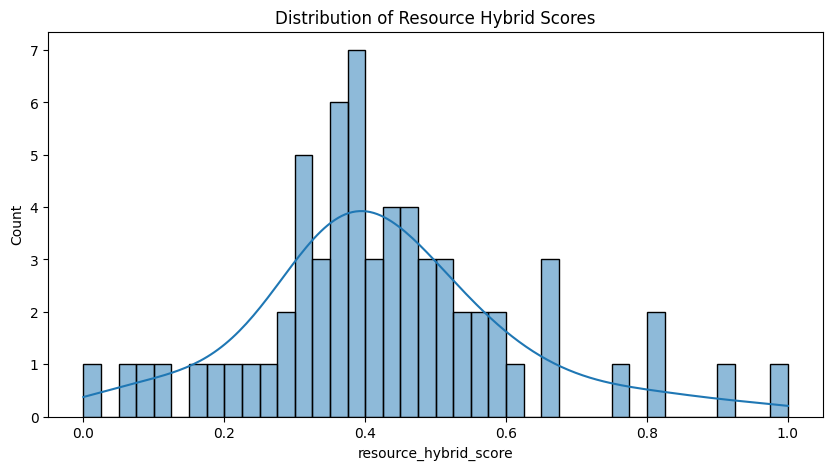

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(res["resource_hybrid_score"], kde=True, bins=40)
plt.title("Distribution of Resource Hybrid Scores")
plt.xlabel("resource_hybrid_score")
plt.show()


In [12]:
import numpy as np
import matplotlib.pyplot as plt

def set_dashboard_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.dpi": 150,
        "axes.edgecolor": "#cccccc",
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
    })

def plot_metric_dashboard(df, metric_cols, titles=None, n_cols=4,
                          suptitle=None, x_axis_label="Index (sorted by metric)"):
    set_dashboard_style()

    n_metrics = len(metric_cols)
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3 * n_cols, 2.2 * n_rows),
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(metric_cols):
        ax = axes[i]
        series = df[col].dropna().sort_values()
        x = np.arange(1, len(series) + 1)

        ax.plot(x, series.values, color="black", linewidth=1.0)
        ax.set_xlim(1, len(series))

        if titles is not None:
            ax.set_title(titles[i])
        else:
            ax.set_title(col.replace("_", " ").title())

        ax.ticklabel_format(axis="y", style="plain", useOffset=False)

        for spine in ["left", "bottom"]:
            ax.spines[spine].set_color("#cccccc")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    for r in range(n_rows):
        for c in range(n_cols):
            idx = r * n_cols + c
            if idx >= n_metrics:
                continue
            ax = axes[idx]
            if r == n_rows - 1:
                ax.set_xlabel(x_axis_label)
            else:
                ax.set_xticklabels([])

    if suptitle is not None:
        fig.suptitle(suptitle, y=1.02, fontsize=11)

    fig.tight_layout()
    return fig, axes

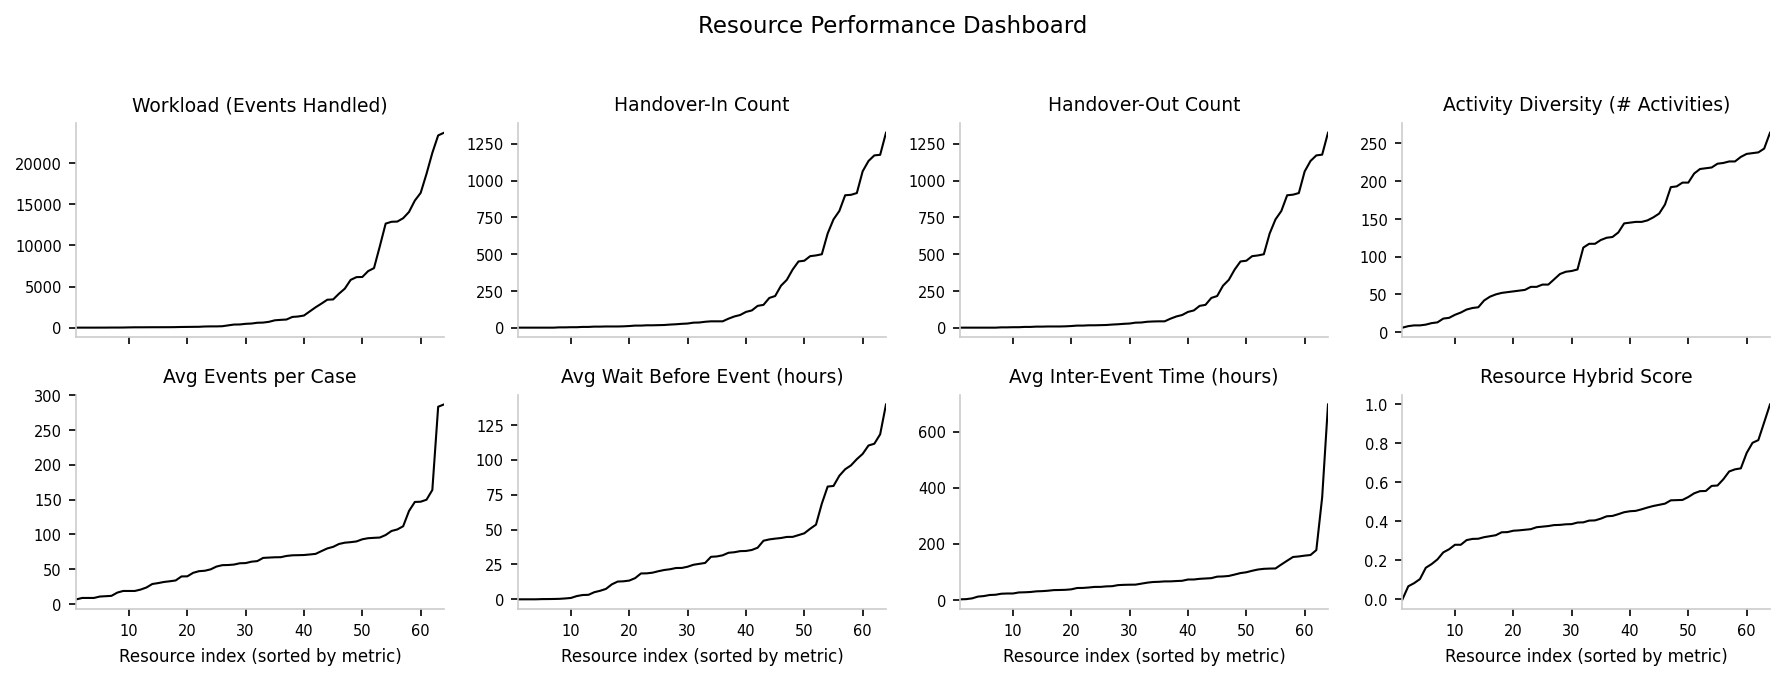

In [13]:
resource_metric_cols = [
    "n_events",
    "handover_in",
    "handover_out",
    "n_distinct_activities",
    "avg_events_per_case",
    "avg_wait_before_event_hours",
    "avg_inter_event_hours",
    "resource_hybrid_score",
]

resource_metric_titles = [
    "Workload (Events Handled)",
    "Handover-In Count",
    "Handover-Out Count",
    "Activity Diversity (# Activities)",
    "Avg Events per Case",
    "Avg Wait Before Event (hours)",
    "Avg Inter-Event Time (hours)",
    "Resource Hybrid Score",
]

fig_res, axes_res = plot_metric_dashboard(
    df=res,
    metric_cols=resource_metric_cols,
    titles=resource_metric_titles,
    n_cols=4,
    suptitle="Resource Performance Dashboard",
    x_axis_label="Resource index (sorted by metric)",
)

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_weight_comparison(weight_data, weight_manual, title, rotation=45):
    """
    Side-by-side bar chart:
    - weight_data:  dict of data-driven weights (PCA+Entropy)
    - weight_manual: dict of standard/manual weights with the same keys
    """
    features = list(weight_data.keys())
    data_vals = [weight_data[f] for f in features]
    manual_vals = [weight_manual[f] for f in features]

    x = np.arange(len(features))
    width = 0.38

    fig, ax = plt.subplots(figsize=(1.6 * len(features), 4))

    # Standard/manual weights
    ax.bar(x - width/2, manual_vals, width,
           label="Standard weights", color="#cccccc", edgecolor="black", linewidth=0.7)
    # Data-driven weights
    ax.bar(x + width/2, data_vals, width,
           label="Data-driven (PCA+Entropy)", color="black", alpha=0.9)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Weight")
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=rotation, ha="right")

    # Minimalist axes, no grid
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax

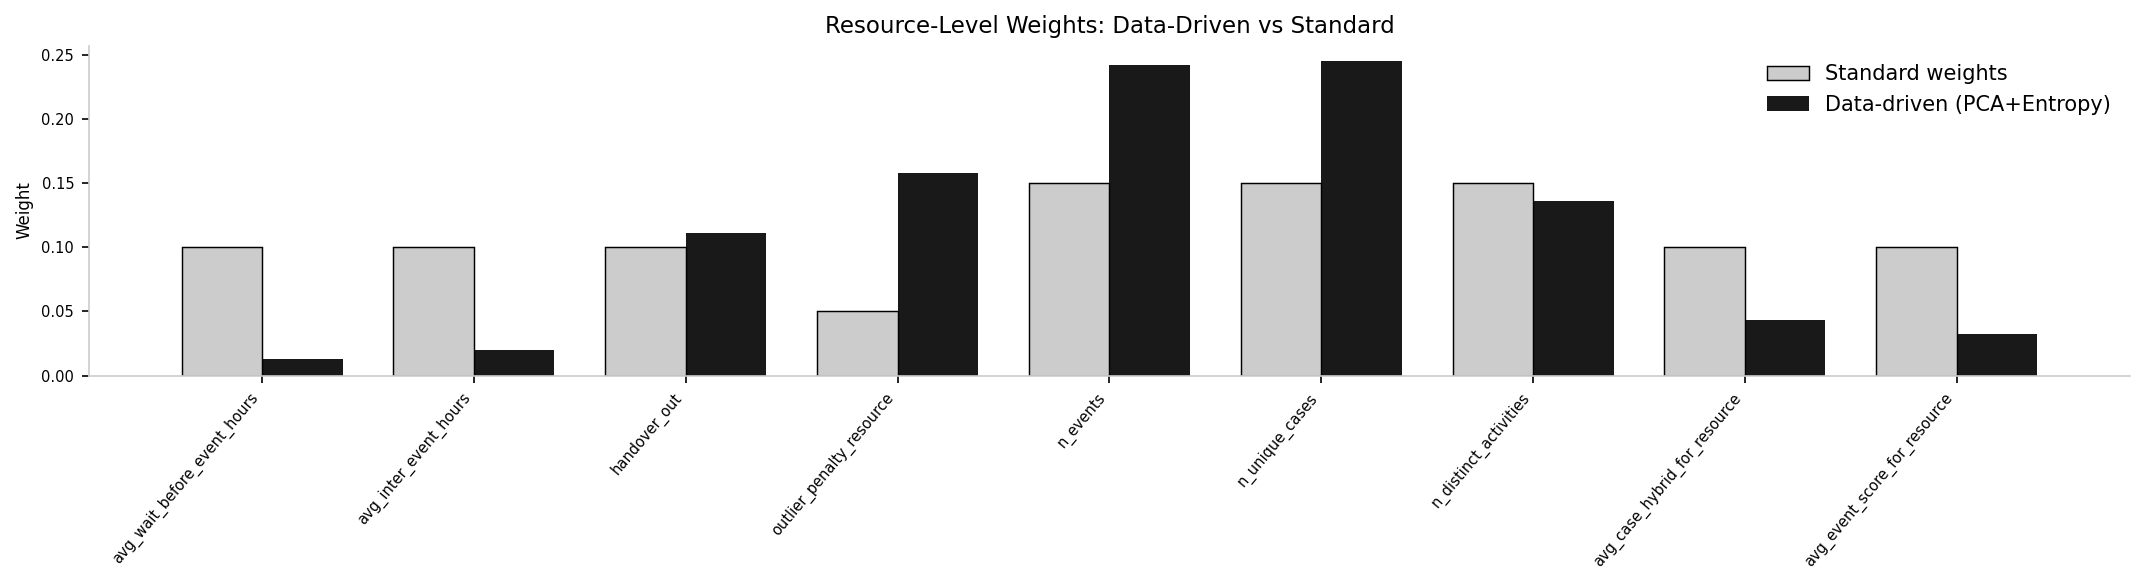

In [15]:
# ----- Standard / manual weights for resource comparison -----
resource_weights_manual = {
    "avg_wait_before_event_hours":     0.10,
    "avg_inter_event_hours":           0.10,
    "handover_out":                    0.10,
    "outlier_penalty_resource":        0.05,
    "n_events":                        0.15,
    "n_unique_cases":                  0.15,
    "n_distinct_activities":           0.15,
    "avg_case_hybrid_for_resource":    0.10,
    "avg_event_score_for_resource":    0.10,
}

total_manual_res = sum(resource_weights_manual.values())
resource_weights_manual = {k: v / total_manual_res for k, v in resource_weights_manual.items()}

# Align to the same feature order as in resource_weights
resource_weights_ordered = {k: resource_weights[k] for k in resource_weights_manual.keys()}

fig_res_w, ax_res_w = plot_weight_comparison(
    weight_data=resource_weights_ordered,
    weight_manual=resource_weights_manual,
    title="Resource-Level Weights: Data-Driven vs Standard",
    rotation=50,
)

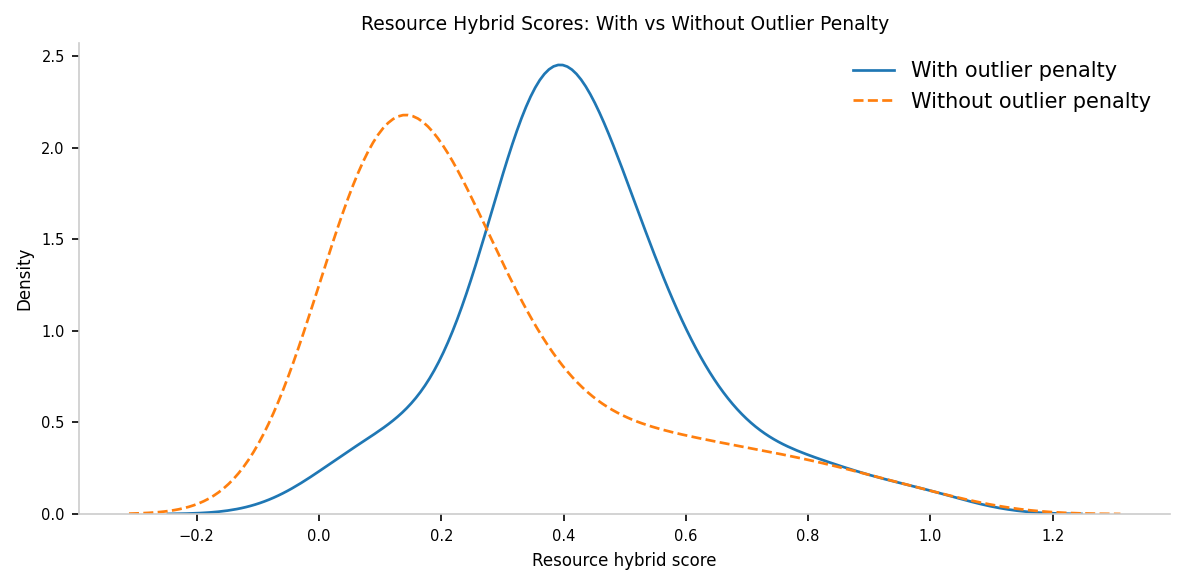

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def recompute_score_without_penalty(norm_df, weights, penalty_col):
    w = weights.copy()
    if penalty_col in w:
        w[penalty_col] = 0.0
        total = sum(w.values())
        w = {k: v / total for k, v in w.items()}

    raw = np.zeros(len(norm_df))
    for col in norm_df.columns:
        raw += norm_df[col].values * w[col]
    score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
    return score

score_with_penalty = res["resource_hybrid_score"].values
score_no_penalty = recompute_score_without_penalty(
    resource_norm, resource_weights, "outlier_penalty_resource"
)

plt.figure(figsize=(8, 4))
sns.kdeplot(score_with_penalty, label="With outlier penalty", linewidth=1.3)
sns.kdeplot(score_no_penalty, label="Without outlier penalty", linewidth=1.3, linestyle="--")

plt.xlabel("Resource hybrid score")
plt.ylabel("Density")
plt.title("Resource Hybrid Scores: With vs Without Outlier Penalty")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()